<!-- filepath: /home/tsilva/repos/tsilva/aiml-notebooks/notebooks/cartpole-dqn-vanilla-solution.ipynb -->
# Solving CartPole-v1 with Vanilla DQN
This notebook demonstrates how to solve the CartPole-v1 environment using a vanilla Deep Q-Network (DQN) implementation. We will train an agent, evaluate its performance, and visualize the results.

## 1. Install and Import Required Libraries
Install and import all necessary packages for DQN, including PyTorch, Gymnasium, NumPy, and Matplotlib.

In [1]:
# If running in Colab or a fresh environment, uncomment the following lines:
# !pip install gymnasium torch matplotlib numpy
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt

## 2. Set Up CartPole-v1 Environment
Initialize the CartPole-v1 environment and inspect its observation and action spaces.

In [2]:
env = gym.make('CartPole-v1')
obs_space = env.observation_space.shape[0]
action_space = env.action_space.n
print(f"Observation space: {obs_space}, Action space: {action_space}")

Observation space: 4, Action space: 2


## 3. Implement the DQN Agent
Define the neural network, replay buffer, and DQN algorithm with epsilon-greedy policy and target network updates.

In [3]:
class DQN(nn.Module):
    def __init__(self, obs_dim, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions)
        )
    def forward(self, x):
        return self.net(x)

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = map(np.array, zip(*batch))
        return state, action, reward, next_state, done
    def __len__(self):
        return len(self.buffer)

In [4]:
def select_action(state, policy_net, epsilon, n_actions):
    if random.random() < epsilon:
        return random.randrange(n_actions)
    else:
        state = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            q_values = policy_net(state)
        return q_values.argmax().item()

def update_target(policy_net, target_net):
    target_net.load_state_dict(policy_net.state_dict())

## 4. Train the DQN Agent
Train the agent on CartPole-v1, logging episode rewards and losses.

In [5]:
# Hyperparameters
num_episodes = 400
batch_size = 64
gamma = 0.99
lr = 1e-3
buffer_capacity = 10000
target_update_freq = 10
epsilon_start = 1.0
epsilon_final = 0.01
epsilon_decay = 300

policy_net = DQN(obs_space, action_space)
target_net = DQN(obs_space, action_space)
update_target(policy_net, target_net)
optimizer = optim.Adam(policy_net.parameters(), lr=lr)
replay_buffer = ReplayBuffer(buffer_capacity)

rewards = []
losses = []
epsilon = epsilon_start

for episode in range(num_episodes):
    state, _ = env.reset()
    episode_reward = 0
    for t in range(1, 10000):
        action = select_action(state, policy_net, epsilon, action_space)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        replay_buffer.push(state, action, reward, next_state, done)
        state = next_state
        episode_reward += reward
        if len(replay_buffer) > batch_size:
            s, a, r, ns, d = replay_buffer.sample(batch_size)
            s = torch.FloatTensor(s)
            a = torch.LongTensor(a)
            r = torch.FloatTensor(r)
            ns = torch.FloatTensor(ns)
            d = torch.FloatTensor(d)
            q_values = policy_net(s).gather(1, a.unsqueeze(1)).squeeze(1)
            next_q_values = target_net(ns).max(1)[0]
            expected_q = r + gamma * next_q_values * (1 - d)
            loss = nn.MSELoss()(q_values, expected_q.detach())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        if done:
            break
    rewards.append(episode_reward)
    epsilon = epsilon_final + (epsilon_start - epsilon_final) * np.exp(-1. * episode / epsilon_decay)
    if episode % target_update_freq == 0:
        update_target(policy_net, target_net)
    if (episode+1) % 50 == 0:
        print(f"Episode {episode+1}, Reward: {episode_reward}, Epsilon: {epsilon:.3f}")

Episode 50, Reward: 36.0, Epsilon: 0.851
Episode 100, Reward: 27.0, Epsilon: 0.722
Episode 100, Reward: 27.0, Epsilon: 0.722
Episode 150, Reward: 16.0, Epsilon: 0.612
Episode 150, Reward: 16.0, Epsilon: 0.612
Episode 200, Reward: 119.0, Epsilon: 0.520
Episode 200, Reward: 119.0, Epsilon: 0.520
Episode 250, Reward: 17.0, Epsilon: 0.442
Episode 250, Reward: 17.0, Epsilon: 0.442
Episode 300, Reward: 115.0, Epsilon: 0.375
Episode 300, Reward: 115.0, Epsilon: 0.375
Episode 350, Reward: 109.0, Epsilon: 0.319
Episode 350, Reward: 109.0, Epsilon: 0.319
Episode 400, Reward: 85.0, Epsilon: 0.272
Episode 400, Reward: 85.0, Epsilon: 0.272


## 5. Evaluate the Trained Agent
Test the trained agent over several episodes and report the average reward.

In [6]:
test_episodes = 10
test_rewards = []
for ep in range(test_episodes):
    state, _ = env.reset()
    ep_reward = 0
    for t in range(1, 10000):
        action = select_action(state, policy_net, 0.0, action_space)  # Greedy
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        state = next_state
        ep_reward += reward
        if done:
            break
    test_rewards.append(ep_reward)
    print(f"Test Episode {ep+1}: Reward = {ep_reward}")
print(f"Average Test Reward over {test_episodes} episodes: {np.mean(test_rewards)}")

Test Episode 1: Reward = 267.0
Test Episode 2: Reward = 227.0
Test Episode 3: Reward = 249.0
Test Episode 4: Reward = 195.0
Test Episode 5: Reward = 222.0
Test Episode 6: Reward = 211.0
Test Episode 7: Reward = 196.0
Test Episode 8: Reward = 191.0
Test Episode 9: Reward = 187.0
Test Episode 10: Reward = 356.0
Average Test Reward over 10 episodes: 230.1
Test Episode 10: Reward = 356.0
Average Test Reward over 10 episodes: 230.1


## 6. Visualize Training Progress
Plot the episode rewards over time to visualize the agent's learning progress.

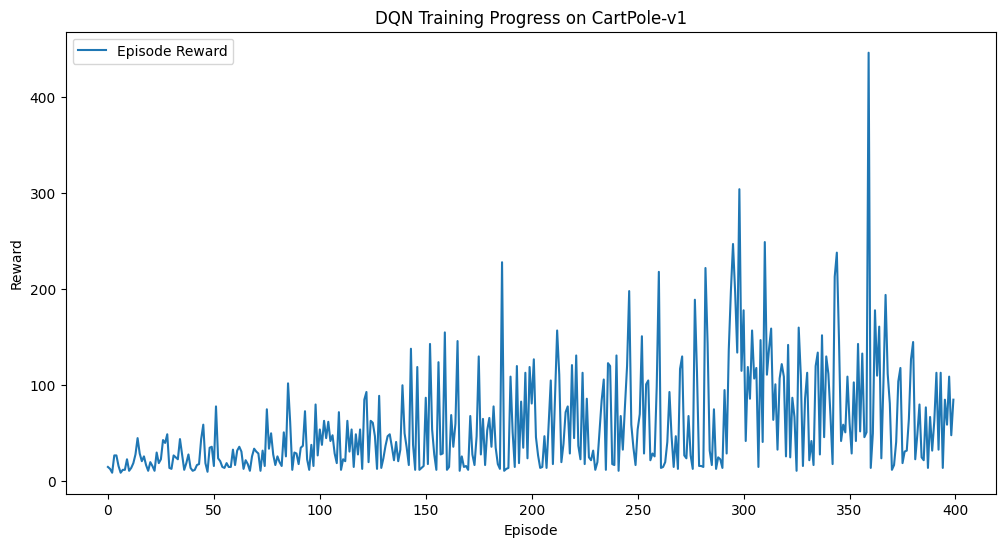

In [7]:
plt.figure(figsize=(12,6))
plt.plot(rewards, label='Episode Reward')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('DQN Training Progress on CartPole-v1')
plt.legend()
plt.show()